In [4]:
from ultralytics import YOLO
import os
from IPython.display import display, Image
from IPython import display
import os
from google.colab import userdata
from ultralytics import YOLO
from roboflow import Roboflow
from roboflow import download_dataset
import supervision as sv
from supervision.metrics import MeanAveragePrecision
import random
display.clear_output()

In [5]:
os.environ['ROBOFLOW_API_KEY'] = userdata.get('ROBOFLOW_API_KEY')

In [6]:
dataset = download_dataset('https://universe.roboflow.com/333-9gp58/gun-and-knife-mvzar/dataset/3#', 'yolov9')


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to gun-and-knife-3 in yolov9:: 100%|██████████| 15884/15884 [00:01<00:00, 9201.87it/s] 


In [7]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [8]:
model = YOLO('yolov10s.yaml')
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=300,
    patience=50,
    imgsz=640,
    batch=64,
    optimizer="AdamW",
    lr0=0.0001,
    cos_lr=True,
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.15,
    workers=8,
    device=0,
    close_mosaic=10,
)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/gun-and-knife-3/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov10s.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=50, perspective=0.0

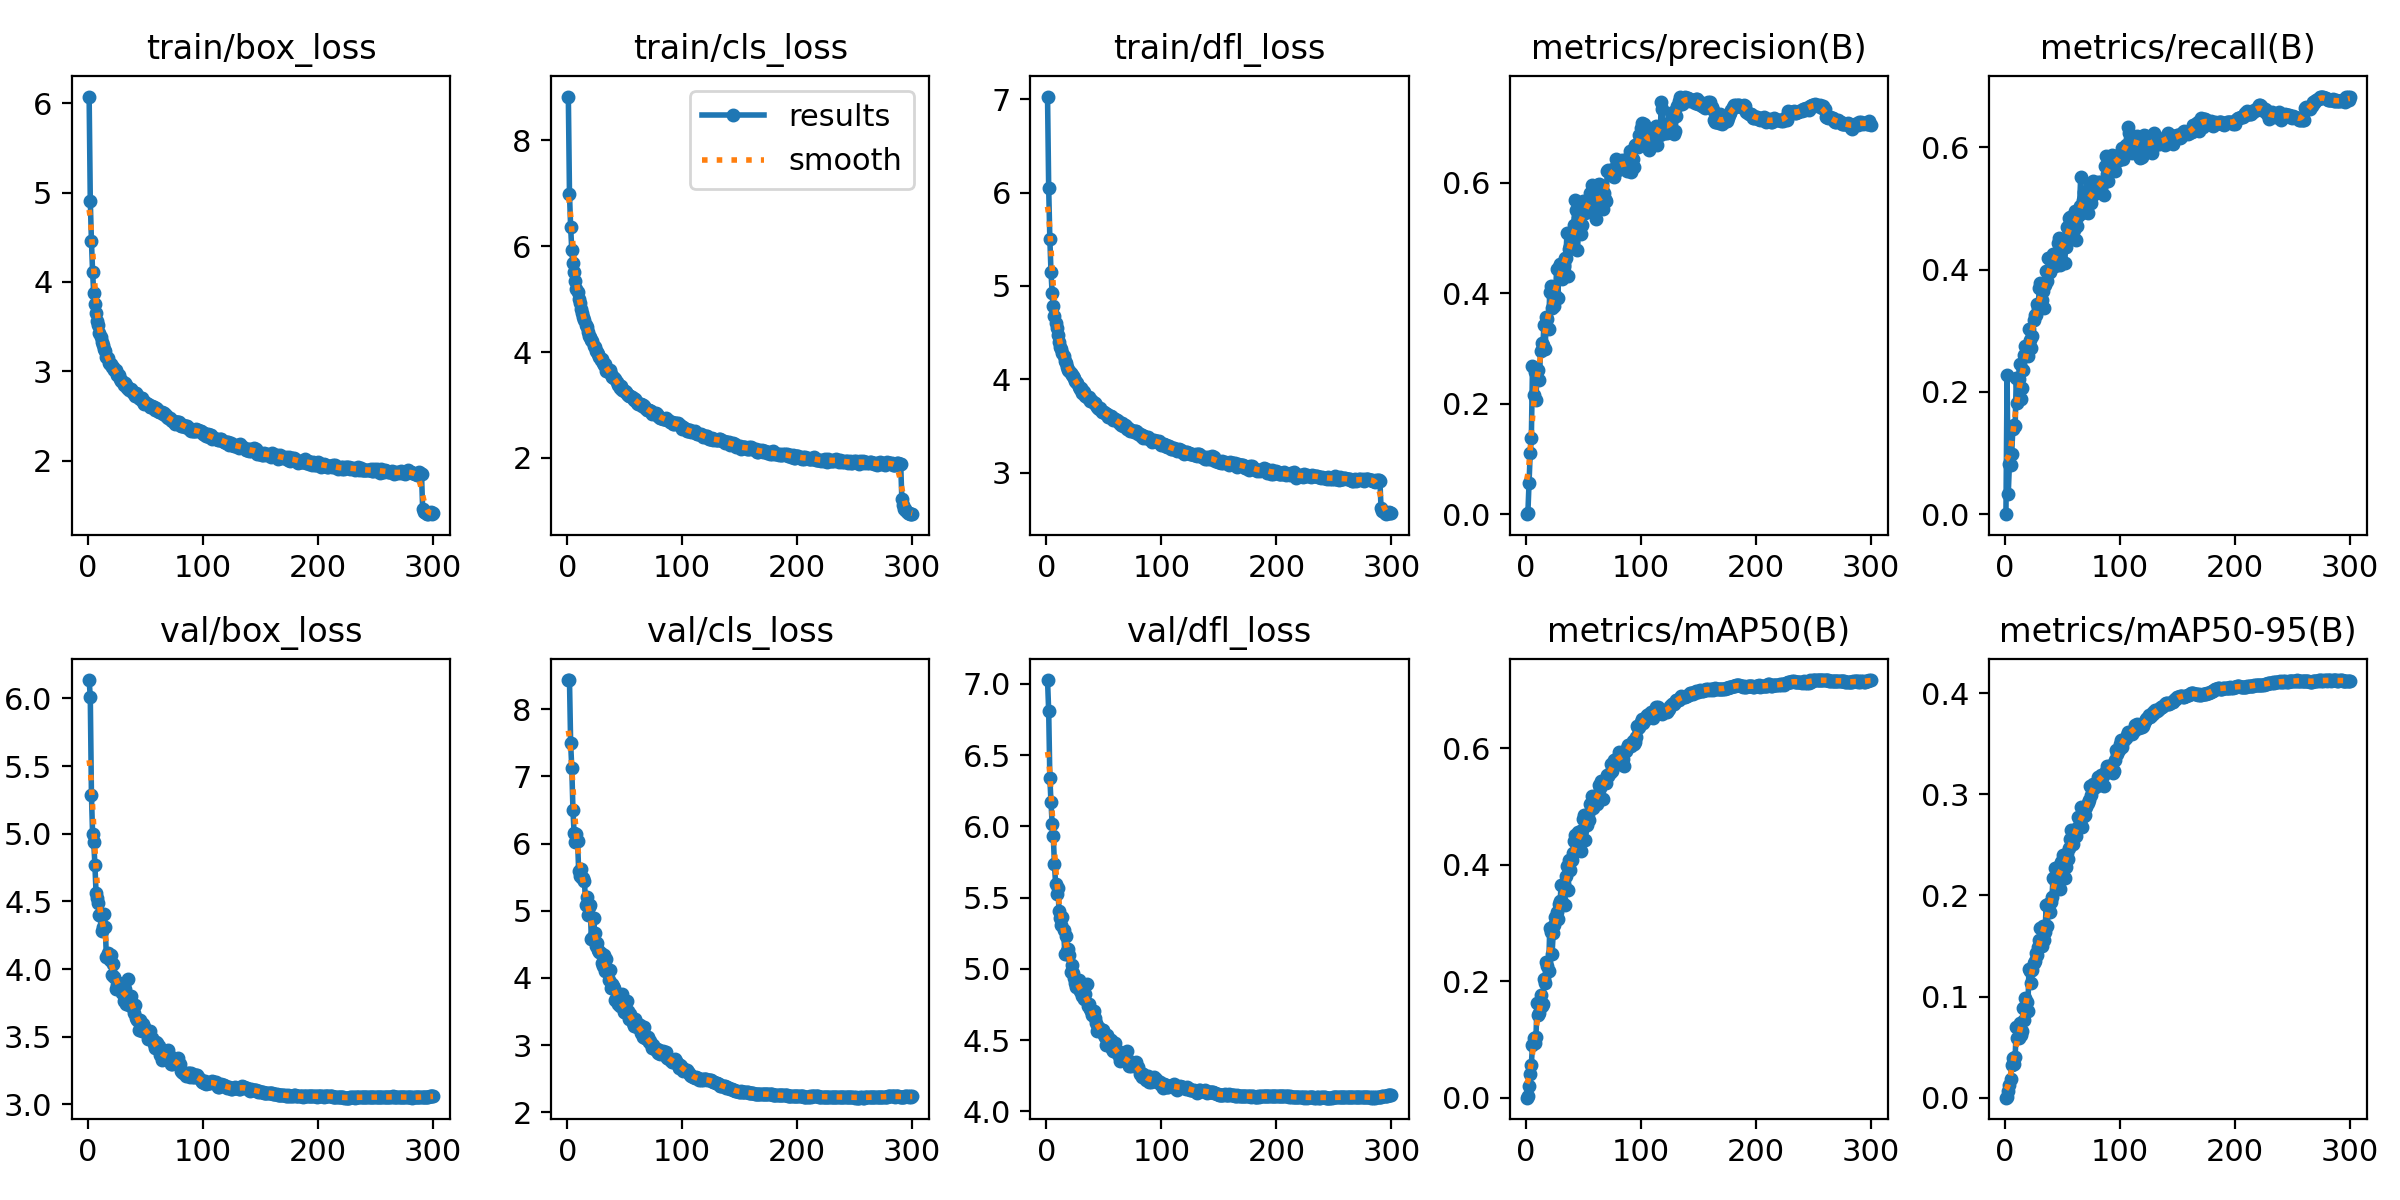

In [9]:
Image(filename=f'/content/runs/detect/train/results.png', width=1000)

In [10]:
ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)
ds.classes

['gun', 'knife']

In [11]:
model = YOLO(f'/content/runs/detect/train/weights/best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [12]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.41299585921031073
mAP 50 0.7153846056756425
mAP 75 0.420529410086911


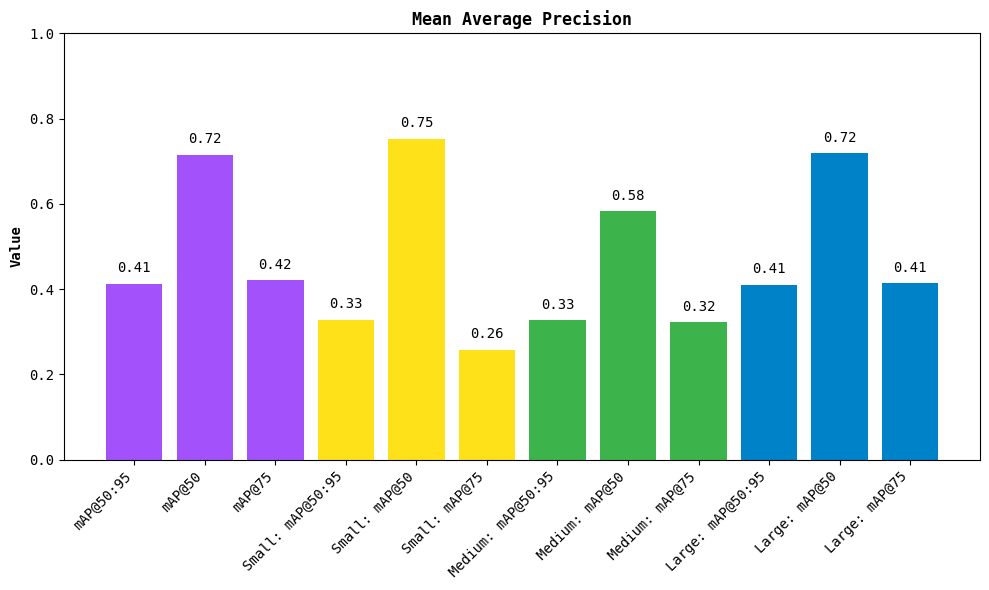

In [13]:
map.plot()

In [14]:
ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

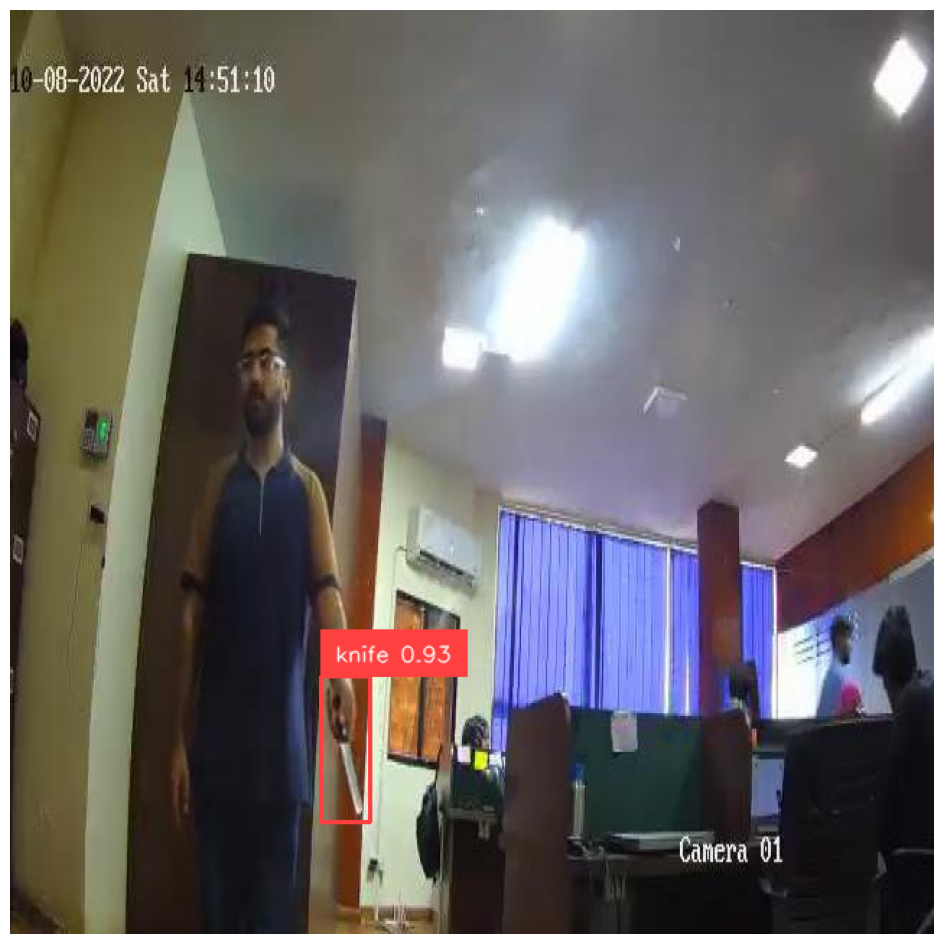

In [71]:
i = random.randint(0, len(ds))
image_path, image, target = ds[i]

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

names = results.names
labels = [
    f"{names[class_id]} {confidence:0.2f}"
    for class_id, confidence in zip(detections.class_id, detections.confidence)
]

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(
    scene=annotated_image,
    detections=detections
)
annotated_image = label_annotator.annotate(
    scene=annotated_image,
    detections=detections,
    labels=labels
)
sv.plot_image(annotated_image)